In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/data_dictionary.csv
/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/train.csv
/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/test.csv


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/data_dictionary.csv
/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/train.csv
/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/test.csv


In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/train.csv')

print(df.head())
print(df.columns)
print(df.info())

   experience  country     education         languages             frameworks  \
0          34  Germany       Masters  Rust, JavaScript           Vue, ASP.NET   
1           9       UK       Masters    C#, JavaScript  Ruby on Rails, Spring   
2           8      USA  Some College           C++, Go             Vue, React   
3          29      USA       Masters         C++, Ruby        Spring, Angular   
4           7      USA     Bachelors          C#, Rust         React, Express   

  company_size  salary_usd  
0     201-1000      172292  
1     201-1000       82311  
2        5000+      109637  
3        11-50      214386  
4         1-10      107584  
Index(['experience', 'country', 'education', 'languages', 'frameworks',
       'company_size', 'salary_usd'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   experience

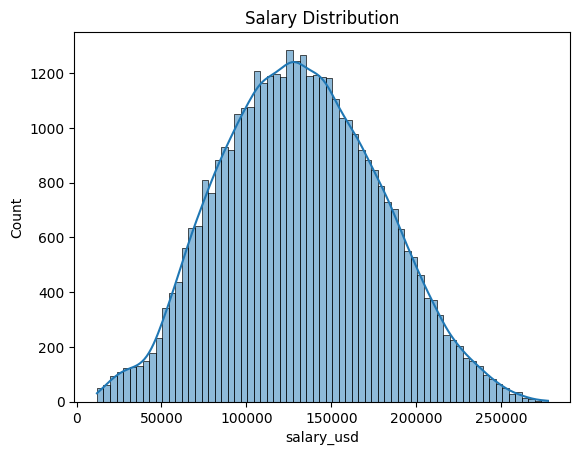

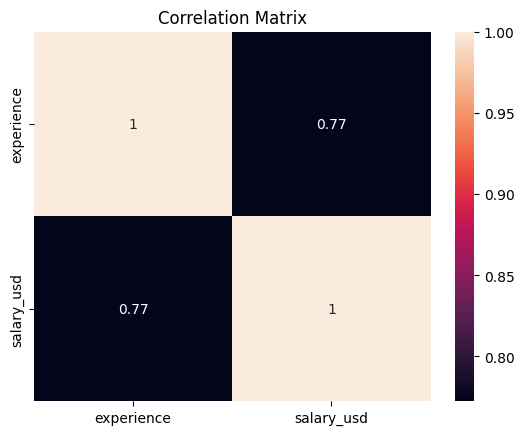

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Salary distribution
sns.histplot(df['salary_usd'], kde=True)
plt.title("Salary Distribution")
plt.show()

# Correlation heatmap (only numeric)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

df_processed = df.copy()

le = LabelEncoder()

# Encode categorical columns
categorical_cols = ['country', 'education', 'languages', 'frameworks', 'company_size']

for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

print(df_processed.head())

   experience  country  education  languages  frameworks  company_size  \
0          34        4          2         84          90             3   
1           9        8          2          4          78             3   
2           8        9          4         12          96             4   
3          29        9          2         17          81             2   
4           7        9          0          8          63             0   

   salary_usd  
0      172292  
1       82311  
2      109637  
3      214386  
4      107584  


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features & Target
X = df_processed.drop('salary_usd', axis=1)
y = df_processed['salary_usd']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Accuracy
score = model.score(X_test, y_test)
print("R2 Score:", score)

R2 Score: 0.70228326886616


In [7]:
import pandas as pd

# Same columns as training data
sample = pd.DataFrame([{
    'experience': 5,
    'country': 9,
    'education': 0,
    'languages': 8,
    'frameworks': 63,
    'company_size': 0
}])

prediction = model.predict(sample)

print("Predicted Salary (USD):", int(prediction[0]))

Predicted Salary (USD): 94924
